# Загрузка датасета и импорты

In [318]:
import kagglehub

path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

In [319]:
import pandas as pd
from IPython.display import display
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [320]:
df = pd.read_csv(path+"/used_cars.csv")

# Гипотезы

1. Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.
2. Добавление элементарных признаков, извлечённых из engine, уменьшит ошибку модели на тестовой выборке.
3. Извлечённый из столбца engine признак horsepower войдёт в число наиболее важных признаков модели на основе деревьев.
4. Random Forest или градиентный бустинг покажет меньшую ошибку на тестовой выборке, чем линейная регрессия.
5. Обучение линейной регрессии на log(price) даст меньшую ошибку, чем обучение на исходном значении price.
6. Медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.

# EDA

## Знакомство с данными

In [321]:
print(df.shape)

(4009, 12)


In [322]:
display(df.head(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [323]:
display(df.sample(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2977,Jeep,Wrangler Rubicon,2009,"130,000 mi.",Gasoline,202.0HP 3.8L V6 Cylinder Engine Gasoline Fuel,6-Speed M/T,Black,Gray,None reported,Yes,"$15,500"
303,Porsche,Cayman S,2007,"5,856 mi.",Gasoline,295.0HP 3.4L Flat 6 Cylinder Engine Gasoline Fuel,6-Speed M/T,Black,Black,None reported,Yes,"$45,000"
203,Ford,GT,2005,"1,897 mi.",Gasoline,5.4 Liter SC DOHC,Manual,White,–,None reported,NaN,"$429,998"
3928,Buick,Enclave Premium,2014,"86,281 mi.",Gasoline,288.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$18,900"
2043,Chevrolet,Suburban Premier,2019,"105,667 mi.",Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Beige,None reported,Yes,"$39,000"
1646,BMW,228 Gran Coupe i xDrive,2020,"31,100 mi.",Gasoline,228.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,8-Speed A/T,Blue,White,None reported,Yes,"$26,999"
1379,Chevrolet,Corvette Base,2008,"28,150 mi.",Gasoline,430.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,None reported,Yes,"$31,000"
1027,Audi,R8 5.2,2014,"21,800 mi.",Gasoline,525.0HP 5.2L 10 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,"$117,000"
1613,BMW,M3 Base,2016,"55,250 mi.",Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Blue,White,None reported,Yes,"$49,999"
2292,Audi,R8 5.2 V10 plus,2017,"61,000 mi.",Gasoline,610.0HP 5.2L 10 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Gray,Black,None reported,Yes,"$140,000"


In [324]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB
None


Сразу видим, что milage и price - строки, но по сущности числовой признак. Поменяем сейчас, чтобы дальше смотреть метрики для чисел.

In [325]:
df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)', expand=False)
    .astype(int)
)

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [326]:
print(df.describe(include='all'))

       brand    model   model_year         milage fuel_type  \
count   4009     4009  4009.000000    4009.000000      3839   
unique    57     1898          NaN            NaN         7   
top     Ford  M3 Base          NaN            NaN  Gasoline   
freq     386       30          NaN            NaN      3309   
mean     NaN      NaN  2015.515590   64717.551010       NaN   
std      NaN      NaN     6.104816   52296.599459       NaN   
min      NaN      NaN  1974.000000     100.000000       NaN   
25%      NaN      NaN  2012.000000   23044.000000       NaN   
50%      NaN      NaN  2017.000000   52775.000000       NaN   
75%      NaN      NaN  2020.000000   94100.000000       NaN   
max      NaN      NaN  2024.000000  405000.000000       NaN   

                            engine transmission ext_col int_col  \
count                         4009         4009    4009    4009   
unique                        1146           62     319     156   
top     2.0L I4 16V GDI DOHC Turbo        

In [327]:
data_info = pd.DataFrame(columns=['Признак', 'Тип', 'Пропуски', 'Уникальные значения'])

data_info.loc[len(data_info)]=['brand', 'категориальный', df['brand'].isna().sum(), df['brand'].unique().size]

data_info.loc[len(data_info)] = ['model', 'категориальный', df['model'].isna().sum(), df['model'].unique().size]

data_info.loc[len(data_info)] = ['model_year', 'числовой', df['model_year'].isna().sum(), df['model_year'].unique().size]

data_info.loc[len(data_info)] = ['milage', 'числовой', df['milage'].isna().sum(), df['milage'].unique().size]

data_info.loc[len(data_info)] = ['fuel_type', 'категориальный', df['fuel_type'].isna().sum(), df['fuel_type'].unique().size]

data_info.loc[len(data_info)] = ['engine', 'составной', df['engine'].isna().sum(), df['engine'].unique().size]

data_info.loc[len(data_info)] = ['transmission', 'составной', df['transmission'].isna().sum(), df['transmission'].unique().size]

data_info.loc[len(data_info)] = ['ext_col', 'категориальный', df['ext_col'].isna().sum(), df['ext_col'].unique().size]

data_info.loc[len(data_info)] = ['int_col', 'категориальный', df['int_col'].isna().sum(), df['int_col'].unique().size]

data_info.loc[len(data_info)] = ['accident', 'бинарный', df['accident'].isna().sum(), df['accident'].unique().size]

data_info.loc[len(data_info)] = ['clean_title', 'бинарный', df['clean_title'].isna().sum(), df['clean_title'].unique().size]

data_info.loc[len(data_info)] = ['price', 'числовая целевая', df['price'].isna().sum(), df['price'].unique().size]

In [328]:
data_info.head(12)

,Признак,Тип,Пропуски,Уникальные значения
0,brand,категориальный,0,57
1,model,категориальный,0,1898
2,model_year,числовой,0,34
3,milage,числовой,0,2818
4,fuel_type,категориальный,170,8
5,engine,составной,0,1146
6,transmission,составной,0,62
7,ext_col,категориальный,0,319
8,int_col,категориальный,0,156
9,accident,бинарный,113,3


Замечаем, что есть составные признаки, которые можно разделить на несколько более элементарных признаков.

Добавляем исходные элементарные признаки:

In [329]:
base_columns = [
    'brand',
    'model',
    'model_year',
    'milage',
    'fuel_type',
    'ext_col',
    'int_col',
    'accident',
    'clean_title',
    'price'
]

df_features = df[base_columns].copy()

display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999


`engine` встречается в нескольких вариантах, например:

1. `354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid`
2. `2.0L I4 16V GDI DOHC Turbo`
3. `3.5 Liter DOHC`
4. `550.0HP 5.0L V8 Cylinder Engine Supercharged`

Из него можно извлечь следующие элементарные признаки:

| Новый признак     | Смысл нового признака                | Тип            | Пример                                                   |
| ----------------- | ------------------------------------ | -------------- | -------------------------------------------------------- |
| `horsepower`      | Мощность двигателя в лошадиных силах | Числовой       | `300.0`, `450.0`                                         |
| `engine_volume`   | Рабочий объём двигателя в литрах     | Числовой       | `2.0`, `3.5`                                             |
| `cylinders`       | Количество цилиндров двигателя       | Числовой       | `4`, `6`, `8`                                            |
| `engine_config`   | Конфигурация двигателя               | Категориальный | `I4`, `I6`, `V6`, `V8`, `H6`, `ROTARY`                   |
| `fuel_type`       | Тип используемого топлива            | Категориальный | `Gasoline`, `Diesel`, `Flex Fuel`, `Gas/Electric Hybrid` |
| `is_turbo`        | Наличие турбонаддува                 | Бинарный       | `0`, `1`                                                 |
| `is_supercharged` | Наличие механического нагнетателя    | Бинарный       | `0`, `1`                                                 |
| `valves`          | Количество клапанов двигателя        | Числовой       | `16`, `24`, `32`                                         |
| `camshaft_type`   | Тип газораспределительного механизма | Категориальный | `DOHC`, `SOHC`, `OHV`                                    |

In [330]:
### horsepower
df_features['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

### engine_volume
df_features['engine_volume'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L|Liter)').astype(float)

### engine_config
engine_configs = [
    r'V\d+',
    r'I\d+',
    r'Straight\s*\d+',
    r'Flat\s*\d+',
    r'W\d+',
    r'H\d+',
    r'Rotary'
]

pattern_engine_config = '|'.join(engine_configs)

df_features['engine_config'] = df['engine'].str.extract(
    f'\\b({pattern_engine_config})\\b',
    flags=re.IGNORECASE
)

# Приводим разные обозначения одной конфигурации к единому формату
engine_config_map = {
    r'(?i)^Straight\s*(\d+)$': r'I\1',
    r'(?i)^Flat\s*(\d+)$': r'H\1'
}

df_features['engine_config'] = (
    df_features['engine_config']
    .replace(engine_config_map, regex=True)
    .str.upper()
)


### cylinders
# Извлекаем количество цилиндров из конфигурации (если там есть цифра)
df_features['cylinders_from_config'] = df_features['engine_config'].str.extract(r'(\d+)').astype('Int64')

# Если есть явное "X Cylinder", берём его, иначе берём из конфигурации
df_features['cylinders'] = df['engine'].str.extract(r'(\d+)\s*Cylinder').astype('Int64')
df_features['cylinders'] = df_features['cylinders'].fillna(df_features['cylinders_from_config'])

# Удаляем промежуточный
df_features.drop(columns=['cylinders_from_config'], inplace=True)

### is_turbo
df_features['is_turbo'] = df['engine'].str.contains(r'\bTurbo\b', flags=re.IGNORECASE, na=False).astype(int)

### is_supercharged
df_features['is_supercharged'] = df['engine'].str.contains(r'\bSupercharged\b', flags=re.IGNORECASE, na=False).astype(int)

### valves
df_features['valves'] = df['engine'].str.extract(r'(\d+)V').astype('Int64')

### camshaft_type
df_features['camshaft_type'] = df['engine'].str.extract(r'(DOHC|SOHC|OHV|OHC)')

Поскольку fuel_type есть в исходных данных, возьмём оттуда fuel_type, а пропуски заполним информацией из engine

In [331]:
df_features['fuel_type'] = (
    df_features['fuel_type']
    .replace({
        '–': pd.NA,
        'not supported': pd.NA
    })
)

In [332]:
fuel_types = [
    'Gasoline/Mild Electric Hybrid',
    'Gas/Electric Hybrid',
    'Mild Electric Hybrid',
    'Plug-In Hybrid',
    'E85 Flex Fuel',
    'Flex Fuel',
    'Gasoline',
    'Diesel',
    'Hybrid',
    'Electric'
]

pattern_fuel = '|'.join(fuel_types)

fuel_from_engine = df['engine'].str.extract(
    f'({pattern_fuel})',
    flags=re.IGNORECASE,
    expand=False,
)

In [333]:
df_features['fuel_type'] = (
    df_features['fuel_type']
    .fillna(fuel_from_engine)
)

In [334]:
display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume,engine_config,cylinders,is_turbo,is_supercharged,valves,camshaft_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7,V6,6,0,0,<NA>,NaN
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,NaN,3.8,V6,6,0,0,24,DOHC
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598,NaN,3.5,NaN,<NA>,0,0,<NA>,DOHC
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500,354.0,3.5,V6,6,0,0,<NA>,NaN
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999,NaN,2.0,I4,4,1,0,16,DOHC


In [335]:
df_features['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
Electric           167
E85 Flex Fuel      139
Diesel             116
NaN                 50
Plug-In Hybrid      34
Name: count, dtype: int64

В некоторых строках пропуски всё равно остались

`transmission` встречается в нескольких вариантах, например:

1. 8-Speed Automatic
2. 6-Speed M/T
3. Automatic CVT
4. 7-Speed Automatic with Auto-Shift
5. Transmission w/Dual Shift Mode

Из него можно извлечь следующие элементарные признаки:

| Новый признак       | Смысл нового признака                               | Тип               | Пример                              |
| ------------------- | --------------------------------------------------- | ----------------- |-------------------------------------|
| `gears`             | Количество передач коробки передач                  | Числовой          | `5`, `6`, `8`, `10`                 |
| `transmission_type` | Тип коробки передач                                 | Категориальный    | `Automatic`, `Manual`, `CVT`, `DCT` |

In [336]:
### gears
df_features['gears'] = (df['transmission'].str.extract(
        r'(\d+)\s*[- ]?(?:Speed|Spd)',
        flags=re.IGNORECASE,
        expand=False
    )
    .astype('Int64')
)
single_speed_mask = df['transmission'].str.contains(
    r'Single[- ]Speed',
    na=False
)

df_features.loc[single_speed_mask, 'gears'] = 1

In [337]:
### transmission_type
transmission_types = [
    'A/T',
    'M/T',
    'CVT',
    'Automatic',
    'Manual',
    'Dual-Clutch',
    'Variable',
    'Auto-Shift',
    'Dual Shift Mode',
    'Fixed Gear'
]

pattern_trans = '|'.join(transmission_types)

df_features['transmission_type'] = (
    df['transmission']
    .str.extract(
        f'({pattern_trans})',
        flags=re.IGNORECASE,
    )
)

# Преобразуем к единому формату автомат и механику
trans_map = {
    'A/T': 'Automatic',
    'M/T': 'Manual'
}

df_features['transmission_type'] = (
    df_features['transmission_type']
    .replace(trans_map)
)

display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume,engine_config,cylinders,is_turbo,is_supercharged,valves,camshaft_type,gears,transmission_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7,V6,6,0,0,<NA>,NaN,6,Automatic
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,NaN,3.8,V6,6,0,0,24,DOHC,8,Automatic
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598,NaN,3.5,NaN,<NA>,0,0,<NA>,DOHC,<NA>,Automatic
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500,354.0,3.5,V6,6,0,0,<NA>,NaN,7,Automatic
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999,NaN,2.0,I4,4,1,0,16,DOHC,8,Automatic


## Обработка пропущенных значений

Отдельно рассмотрим:

1. исходные признаки, скопированные из исходного датасета;
2. новые признаки, полученные из составных признаков

Это позволит определить, какие пропуски присутствовали в исходных данных, а какие появились

In [338]:
new_columns = [
    column
    for column in df_features.columns
    if column not in base_columns
]

In [339]:
missing_base = pd.DataFrame({
    'Пропуски': (
        df_features[base_columns]
        .isna()
        .sum()
    ),
    'Доля пропусков, %': (
        df_features[base_columns]
        .isna()
        .mean() * 100
    ).round(2)
})

missing_base = (
    missing_base[
        missing_base['Пропуски'] > 0
    ]
    .sort_values(
        by='Доля пропусков, %',
        ascending=False
    )
)

display(missing_base)

,Пропуски,"Доля пропусков, %"
clean_title,596,14.87
accident,113,2.82
fuel_type,50,1.25


Теперь рассмотрим пропуски в новых признаках:

In [340]:
missing_new = pd.DataFrame({
    'Пропуски': (
        df_features[new_columns]
        .isna()
        .sum()
    ),
    'Доля пропусков, %': (
        df_features[new_columns]
        .isna()
        .mean() * 100
    ).round(2)
})

missing_new = (
    missing_new[
        missing_new['Пропуски'] > 0
    ]
    .sort_values(
        by='Доля пропусков, %',
        ascending=False
    )
)

display(missing_new)

,Пропуски,"Доля пропусков, %"
valves,3488,87.00
camshaft_type,3439,85.78
engine_config,2256,56.27
gears,1835,45.77
horsepower,808,20.15
cylinders,420,10.48
engine_volume,217,5.41
transmission_type,23,0.57


В признаках `valves` и `camshaft_type` отсутствует более 80% значений. Заполнение такого количества пропусков медианой или наиболее частой категорией привело бы к появлению большого количества искусственных значений.

Поэтому удалим эти признаки.

In [341]:
columns_to_drop = [
    'valves',
    'camshaft_type'
]

df_features.drop(
    columns=columns_to_drop,
    inplace=True
)

Пропуски в категориальных признаках заполним отдельной категорией Unknown.
Не будем заменять их наиболее частым значением, поскольку отсутствие информации само по себе может быть связано с ценой автомобиля.

In [342]:
categorical_columns = [
    'fuel_type',
    'engine_config',
    'transmission_type',
    'accident',
    'clean_title'
]

for column in categorical_columns:
    df_features[column] = (
        df_features[column]
        .fillna('Unknown')
    )

Пропуски в числовых признаках заполним медианой. Медиана менее чувствительна к выбросам, чем среднее арифметическое.

Дополнительно создадим бинарные признаки, показывающие, было ли исходное значение пропущено. Это позволит модели учитывать сам факт отсутствия информации.

In [343]:
numeric_columns = [
    'horsepower',
    'engine_volume',
    'cylinders',
    'gears'
]


for column in numeric_columns:
    # доп бинарный признак
    df_features[f'{column}_was_missing'] = (
        df_features[column]
        .isna()
        .astype(int)
    )

    # Заполняем пропуски медианой
    median_value = df_features[column].median()

    df_features[column] = (
        df_features[column]
        .fillna(median_value)
    )

In [344]:
missing_data_after = pd.DataFrame({
    'Пропуски': df_features.isna().sum(),
    'Доля пропусков, %': (
        df_features.isna().mean() * 100
    ).round(2)
})

display(
    missing_data_after[
        missing_data_after['Пропуски'] > 0
    ]
)

,Пропуски,"Доля пропусков, %"


# Графический анализ данных

## распределение цены

Сначала рассмотрим распределение цены автомобилей.

In [345]:
print(
    'Средняя цена:',
    round(df_features['price'].mean(), 2)
)

print(
    'Медианная цена:',
    round(df_features['price'].median(), 2)
)

print(
    'Максимальная цена:',
    df_features['price'].max()
)

Средняя цена: 44553.19
Медианная цена: 31000.0
Максимальная цена: 2954083


В датасете присутствуют отдельные автомобили с очень высокой ценой. Из-за них основная часть распределения может быть плохо видна. Поэтому для первого графика исключим 1% самых дорогих автомобилей

Также построим распределение log(price). Логарифмирование уменьшает влияние очень дорогих автомобилей и позволяет проверить целесообразность обучения модели на логарифме целевой переменной.

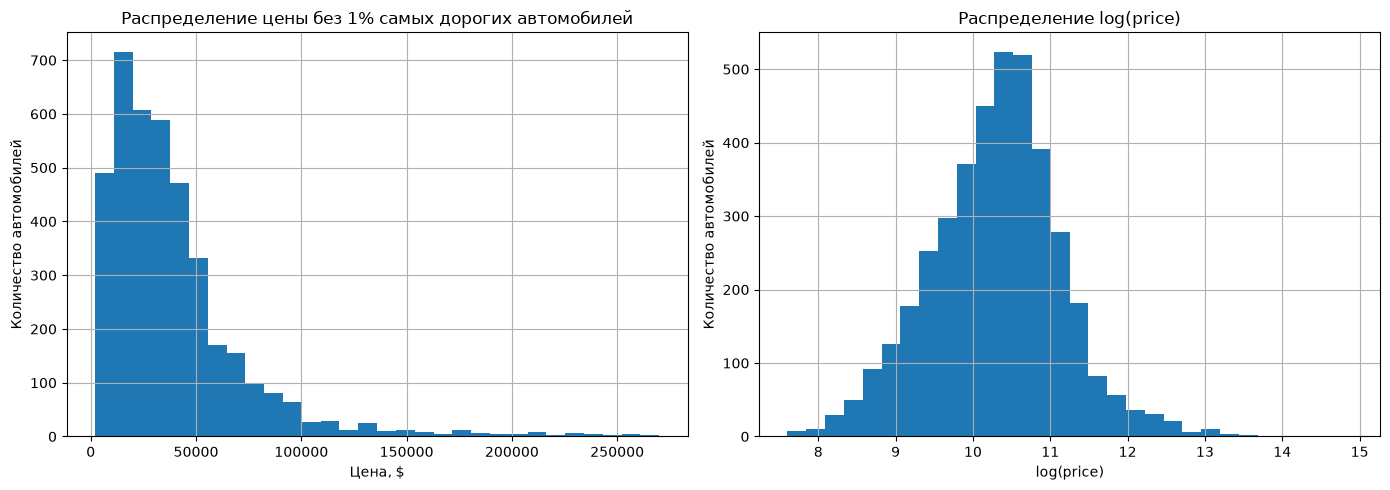

In [346]:
price_99 = (
    df_features['price']
    .quantile(0.99)
)

price_without_extreme = df_features[
    df_features['price'] <= price_99
]['price']

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].hist(
    price_without_extreme,
    bins=30
)

axes[0].set_title(
    'Распределение цены без 1% самых дорогих автомобилей'
)

axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество автомобилей')
axes[0].grid(True)

axes[1].hist(
    np.log1p(df_features['price']),
    bins=30
)

axes[1].set_title(
    'Распределение log(price)'
)

axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('Количество автомобилей')
axes[1].grid(True)

fig.tight_layout()
plt.show()

Средняя цена заметно выше медианной цены. Кроме того, на гистограмме присутствует длинный правый хвост.

Следовательно, распределение цены скошено вправо из-за небольшого количества очень дорогих автомобилей. Поэтому медиана лучше описывает цену типичного автомобиля, чем среднее арифметическое.

## Распределение автомобилей по маркам

Поскольку уникальных марок много, отобразим десять наиболее часто встречающихся.

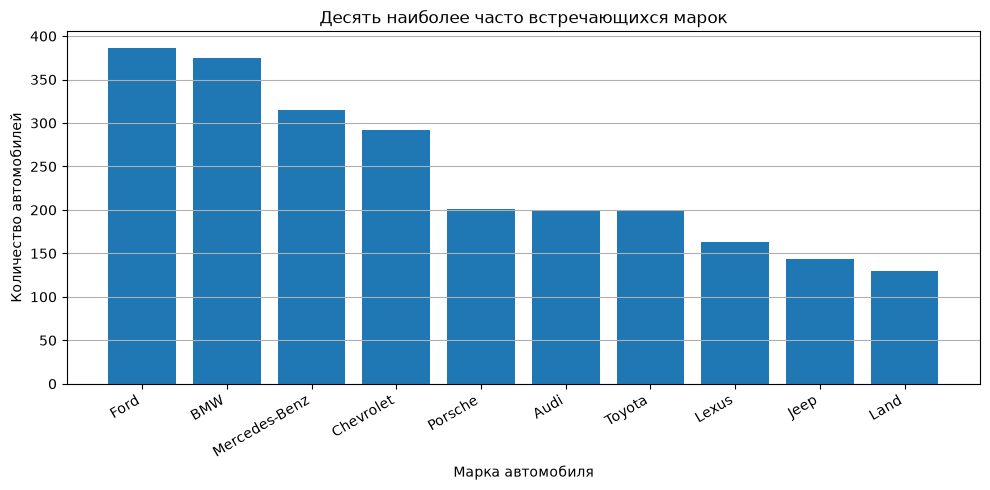

In [347]:
brand_counts = (
    df_features['brand']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(brand_counts)
)

ax.bar(
    x,
    brand_counts.values
)

ax.set_xticks(x)

ax.set_xticklabels(
    brand_counts.index,
    rotation=30,
    ha='right'
)

ax.set_title(
    'Десять наиболее часто встречающихся марок'
)

ax.set_xlabel('Марка автомобиля')
ax.set_ylabel('Количество автомобилей')
ax.grid(axis='y')

fig.tight_layout()
plt.show()

Некоторые марки встречаются значительно чаще остальных.

Это следует учитывать при анализе зависимости цены от марки автомобиля: результаты для редко встречающихся марок могут быть менее устойчивыми.

## Цена и аварийная история

Проверим гипотезу о том, что автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.

Чтобы отдельные очень дорогие автомобили не сжимали основную часть графика, ограничим ось Y значением 99-го процентиля.

In [348]:
accident_categories = [
    'None reported',
    'At least 1 accident or damage reported'
]

accident_labels = [
    'Без аварий',
    'Есть авария или повреждение'
]

price_by_accident = []

for category in accident_categories:
    prices = df_features[
        df_features['accident'] == category
    ]['price']

    price_by_accident.append(prices)

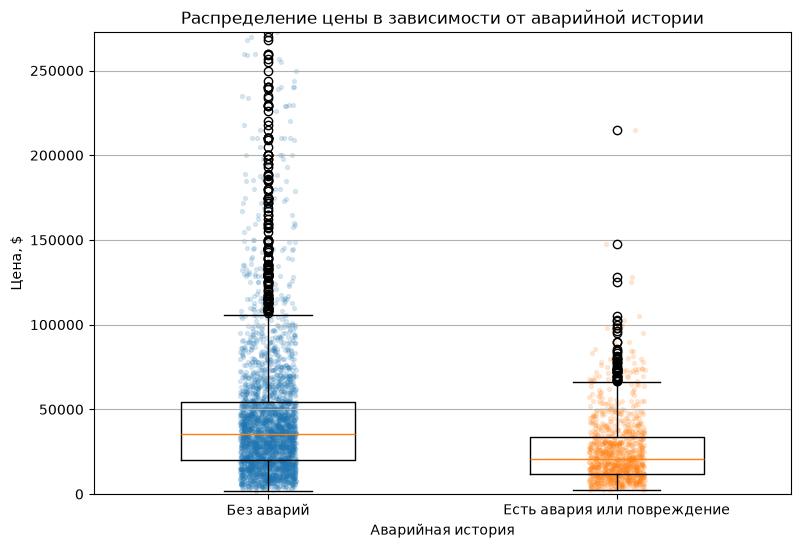

In [349]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.boxplot(
    price_by_accident,
    widths=0.5
)

x = np.arange(
    1,
    len(accident_categories) + 1
)

for i in range(
    len(price_by_accident)
):
    y = price_by_accident[i]

    x_jitter = (
        x[i]
        + np.random.uniform(
            -0.08,
            0.08,
            len(y)
        )
    )

    ax.scatter(
        x_jitter,
        y,
        s=8,
        alpha=0.15
    )

ax.set_xticks(x)
ax.set_xticklabels(
    accident_labels
)

ax.set_title(
    'Распределение цены в зависимости от аварийной истории'
)

ax.set_xlabel(
    'Аварийная история'
)

ax.set_ylabel('Цена, $')

ax.set_ylim(
    0,
    df_features['price'].quantile(0.99)
)

ax.grid(axis='y')

plt.show()

In [350]:
accident_price = (
    df_features[
        df_features['accident'].isin(
            accident_categories
        )
    ]
    .groupby('accident')['price']
    .agg([
        'count',
        'median',
        'mean'
    ])
)

display(accident_price)

,count,median,mean
accident,,,
At least 1 accident or damage reported,986,20900.0,28831.500000
None reported,2910,35667.5,49638.073196


Сравнивать группы лучше по медианной цене, поскольку средняя цена чувствительна к редким очень дорогим автомобилям.

Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с авариями или повреждениями.
Следовательно, полученный результат согласуется с выдвинутой гипотезой.

## Цена и тип топлива

Проверим гипотезу о том, что медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.

,count,median,mean
fuel_group,,,
Gasoline,3309,29950.0,44538.525839
Hybrid,228,44998.0,50609.000000
Electric,167,47000.0,54207.485030


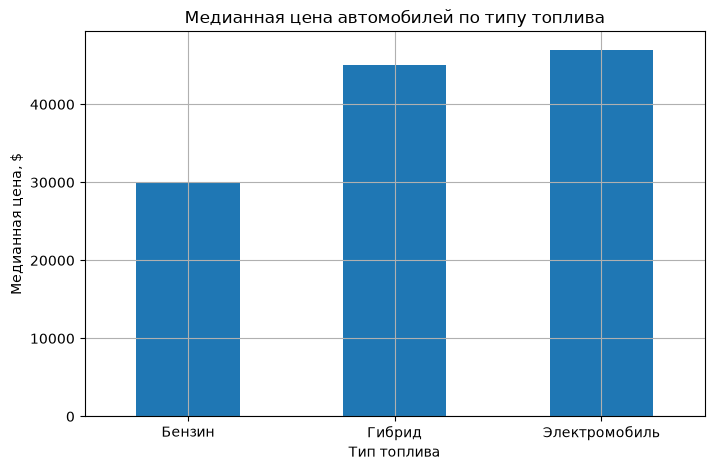

In [351]:
fuel = df_features['fuel_type']

fuel_stats = (
    df_features
    .assign(
        fuel_group=np.select(
            [
                fuel.str.contains('Hybrid', case=False, na=False),
                fuel.str.fullmatch('Electric', case=False, na=False),
                fuel.str.fullmatch('Gasoline', case=False, na=False)
            ],
            ['Hybrid', 'Electric', 'Gasoline'],
            default='Other'
        )
    )
    .query("fuel_group != 'Other'")
    .groupby('fuel_group')['price']
    .agg(['count', 'median', 'mean'])
    .reindex(['Gasoline', 'Hybrid', 'Electric'])
)

display(fuel_stats)

ax = fuel_stats['median'].plot.bar(
    figsize=(8, 5),
    grid=True
)

ax.set(
    title='Медианная цена автомобилей по типу топлива',
    xlabel='Тип топлива',
    ylabel='Медианная цена, $'
)

ax.set_xticklabels(
    ['Бензин', 'Гибрид', 'Электромобиль'],
    rotation=0
)

plt.show()

Медианные цены автомобилей различаются в зависимости от типа топлива.

## Связь цены с числовыми признаками (проверка гипотезы 3)

Для предварительной проверки зависимости цены от мощности двигателя построим корреляционную матрицу.

In [352]:
correlation_columns = [
    'model_year',
    'milage',
    'horsepower',
    'engine_volume',
    'cylinders',
    'gears',
    'is_turbo',
    'is_supercharged',
    'price'
]

corr_data = (
    df_features[
        correlation_columns
    ]
    .copy()
)

In [353]:
corr_matrix = corr_data.corr()

display(corr_matrix)

,model_year,milage,horsepower,engine_volume,cylinders,gears,is_turbo,is_supercharged,price
model_year,1.000000,-0.617720,0.239563,-0.111506,-0.117691,0.300884,0.233450,0.034682,0.199496
milage,-0.617720,1.000000,-0.293725,0.073332,0.015391,-0.193242,-0.197723,-0.036603,-0.305528
horsepower,0.239563,-0.293725,1.000000,0.518724,0.585546,0.078838,-0.045931,-0.007235,0.267426
engine_volume,-0.111506,0.073332,0.518724,1.000000,0.862165,0.008681,-0.138640,0.030821,0.175295
cylinders,-0.117691,0.015391,0.585546,0.862165,1.000000,0.029838,-0.090207,0.035721,0.262547
gears,0.300884,-0.193242,0.078838,0.008681,0.029838,1.000000,0.177315,0.031254,0.090858
is_turbo,0.233450,-0.197723,-0.045931,-0.138640,-0.090207,0.177315,1.000000,-0.012694,0.139124
is_supercharged,0.034682,-0.036603,-0.007235,0.030821,0.035721,0.031254,-0.012694,1.000000,0.020903
price,0.199496,-0.305528,0.267426,0.175295,0.262547,0.090858,0.139124,0.020903,1.000000


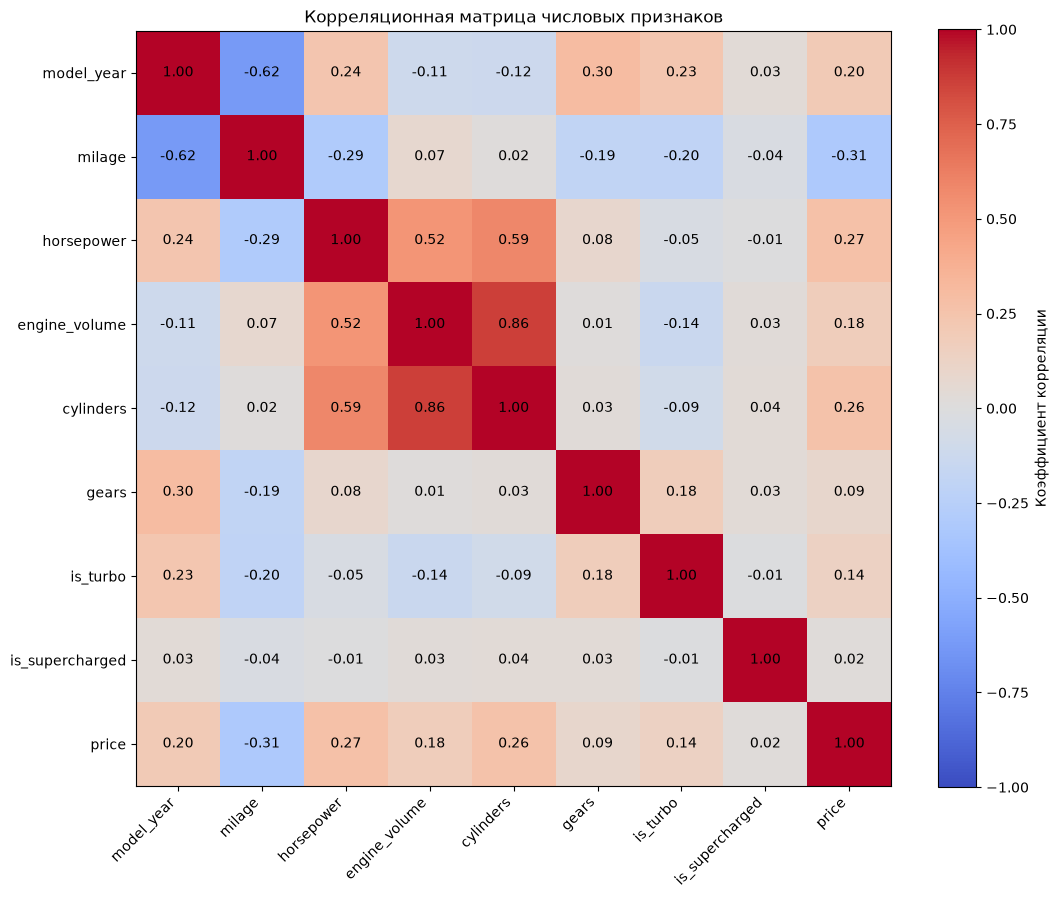

In [354]:
fig, ax = plt.subplots(
    figsize=(11, 9)
)

image = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap='coolwarm'
)

ax.set_xticks(
    np.arange(
        len(correlation_columns)
    )
)

ax.set_yticks(
    np.arange(
        len(correlation_columns)
    )
)

ax.set_xticklabels(
    correlation_columns,
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    correlation_columns
)

for i in range(
    corr_matrix.shape[0]
):
    for j in range(
        corr_matrix.shape[1]
    ):
        ax.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

ax.set_title(
    'Корреляционная матрица числовых признаков'
)

fig.colorbar(
    image,
    ax=ax,
    label='Коэффициент корреляции'
)

fig.tight_layout()
plt.show()

In [355]:
price_correlations = (
    corr_matrix['price']
    .drop('price')
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    price_correlations.to_frame(
        name='Корреляция с price'
    )
)

,Корреляция с price
milage,-0.305528
horsepower,0.267426
cylinders,0.262547
model_year,0.199496
engine_volume,0.175295
is_turbo,0.139124
gears,0.090858
is_supercharged,0.020903


Наиболее сильная связь с ценой наблюдается у признака `milage`. Связь отрицательная.

Между мощностью двигателя `horsepower` и ценой наблюдается положительная корреляция `0.27`. Это предварительно подтверждает гипотезу о том, что более мощные автомобили в среднем стоят дороже. Однако связь является слабой.

Наиболее сильная зависимость наблюдается между признаками `engine_volume` и `cylinders`: коэффициент корреляции равен `0.86`.


Поскольку `engine_volume` является более подробным числовым признаком и содержит меньше пропусков, можно оставить его, а `cylinders` удалить.

# Подготовка признаков к моделированию

In [356]:
df_model = df_features.copy()

display(df_model.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,...,engine_config,cylinders,is_turbo,is_supercharged,gears,transmission_type,horsepower_was_missing,engine_volume_was_missing,cylinders_was_missing,gears_was_missing
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300,...,V6,6,0,0,6,Automatic,0,0,0,0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,...,V6,6,0,0,8,Automatic,1,0,0,0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,Unknown,54598,...,Unknown,6,0,0,7,Automatic,1,0,1,1
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500,...,V6,6,0,0,7,Automatic,0,0,0,0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,Unknown,34999,...,I4,4,1,0,8,Automatic,1,0,0,0


## Преобразование категориальных признаков

Преобразуем их с помощью One-Hot Encoding.

In [357]:
categorical_columns = [
    'brand',
    'model',
    'fuel_type',
    'ext_col',
    'int_col',
    'engine_config',
    'transmission_type'
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_columns,
    dtype=int
)

In [358]:
display(df_model.head())

,model_year,milage,accident,clean_title,price,horsepower,engine_volume,cylinders,is_turbo,is_supercharged,...,engine_config_V8,engine_config_W12,engine_config_W16,transmission_type_Automatic,transmission_type_CVT,transmission_type_Dual Shift Mode,transmission_type_Fixed Gear,transmission_type_Manual,transmission_type_Unknown,transmission_type_Variable
0,2013,51000,At least 1 accident or damage reported,Yes,10300,300.0,3.7,6,0,0,...,0,0,0,1,0,0,0,0,0,0
1,2021,34742,At least 1 accident or damage reported,Yes,38005,310.0,3.8,6,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2022,22372,None reported,Unknown,54598,310.0,3.5,6,0,0,...,0,0,0,1,0,0,0,0,0,0
3,2015,88900,None reported,Yes,15500,354.0,3.5,6,0,0,...,0,0,0,1,0,0,0,0,0,0
4,2021,9835,None reported,Unknown,34999,310.0,2.0,4,1,0,...,0,0,0,1,0,0,0,0,0,0


## Преобразование бинарных признаков

Перед кодированием создадим дополнительные бинарные признаки, указывающие на отсутствие исходной информации. После этого основные бинарные признаки преобразуем в значения 0 и 1

In [359]:
df_model['accident_was_missing'] = (
    df_model['accident']
    .eq('Unknown')
    .astype(int)
)

In [360]:
accident_map = {
    'None reported': 0,
    'At least 1 accident or damage reported': 1,
    'Unknown': 0
}

df_model['accident'] = (
    df_model['accident']
    .map(accident_map)
    .astype(int)
)

Здесь значение 0 для Unknown не означает, что аварий точно не было. Отличить неизвестную информацию позволяет дополнительный признак

In [361]:
df_model['clean_title'] = (
    df_model['clean_title']
    .eq('Yes')
    .astype(int)
)

Остальные бинарные в int:

In [362]:
binary_columns = [
    'accident',
    'clean_title',
    'is_turbo',
    'is_supercharged',
    'horsepower_was_missing',
    'engine_volume_was_missing',
    'cylinders_was_missing',
    'gears_was_missing',
    'accident_was_missing',
]

for column in binary_columns:
    df_model[column] = (
        df_model[column]
        .astype(int)
    )

## Преобразование числовых признаков

К целочисленному типу int относятся признаки:
1. model_year — год выпуска автомобиля;
2. milage — пробег автомобиля;
3. horsepower — мощность двигателя в лошадиных силах;
4. cylinders — количество цилиндров;
5. gears — количество передач;
7. price — цена автомобиля.

Признак engine_volume приведём к типу float

In [363]:
integer_columns = [
    'model_year',
    'milage',
    'horsepower',
    'cylinders',
    'gears',
    'price'
]

for column in integer_columns:
    df_model[column] = (
        df_model[column]
        .round()
        .astype(int)
    )

df_model['engine_volume'] = (
    df_model['engine_volume']
    .astype(float)
)

## Обучение

Обучим несколько моделей для прогнозирования цены автомобиля:

1. линейную регрессию;
2. Lasso-регрессию;
3. случайный лес;
4. линейную регрессию на `log(price)`.

Качество моделей будем оценивать на:

- `MAE`
- `RMSE`
- `R²`

In [364]:
X = df_model.drop(
    columns=['price']
)

y = df_model['price']

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [365]:
print(
    'Размер обучающей выборки:',
    X_train.shape
)

print(
    'Размер тестовой выборки:',
    X_test.shape
)

Размер обучающей выборки: (3207, 2472)
Размер тестовой выборки: (802, 2472)


Удаление cylinders

In [366]:
X_train_without_cylinders = (
    X_train.drop(
        columns=['cylinders']
    )
)

X_test_without_cylinders = (
    X_test.drop(
        columns=['cylinders']
    )
)

## Расчёт метрик

In [367]:
model_results = []

def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    model_results.append({
        'Модель': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

    print(
        'MAE:',
        round(mae, 2)
    )

    print(
        'RMSE:',
        round(rmse, 2)
    )

    print(
        'R2:',
        round(r2, 4)
    )

## Линейная регрессия

In [368]:
linear_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        LinearRegression()
    )
])

linear_model.fit(
    X_train_without_cylinders,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [369]:
linear_predictions = (
    linear_model.predict(
        X_test_without_cylinders
    )
)

evaluate_model(
    'Linear Regression',
    y_test,
    linear_predictions
)

MAE: 21270.61
RMSE: 138166.62
R2: 0.066


Проверим гипотезу о том, что добавление элементарных признаков, извлечённых из `engine`, уменьшает ошибку модели.

Для этого обучим вторую линейную регрессию без соответсвующих признаков.

In [370]:
engine_columns = [
    'horsepower',
    'engine_volume',
    'is_turbo',
    'is_supercharged',
    'horsepower_was_missing',
    'engine_volume_was_missing',
    'cylinders_was_missing'
]

engine_config_columns = [
    column
    for column in X_train_without_cylinders.columns
    if column.startswith('engine_config_')
]

engine_columns = (
    engine_columns
    + engine_config_columns
)

In [371]:
X_train_without_engine = (
    X_train_without_cylinders.drop(
        columns=engine_columns
    )
)

X_test_without_engine = (
    X_test_without_cylinders.drop(
        columns=engine_columns
    )
)

In [372]:
linear_without_engine = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        LinearRegression()
    )
])

linear_without_engine.fit(
    X_train_without_engine,
    y_train
)

predictions_without_engine = (
    linear_without_engine.predict(
        X_test_without_engine
    )
)

In [373]:
mae_with_engine = mean_absolute_error(
    y_test,
    linear_predictions
)

mae_without_engine = mean_absolute_error(
    y_test,
    predictions_without_engine
)

print(
    'MAE с признаками из engine:',
    round(mae_with_engine, 2)
)

print(
    'MAE без признаков из engine:',
    round(mae_without_engine, 2)
)

MAE с признаками из engine: 21270.61
MAE без признаков из engine: 21138.28


После добавления новых признаков MAE увеличилось на `$132.33`, то есть качество модели незначительно ухудшилось.

## Lasso-регрессия

Отдельно попробуем автоматически исключить признак `cylinders` и другие с помощью Lasso-регрессии

In [374]:
lasso_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        LassoCV(
            cv=5,
            max_iter=20000,
            n_jobs=-1,
            selection='random',
            random_state=42
        )
    )
])

lasso_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [375]:
lasso_predictions = (
    lasso_model.predict(
        X_test
    )
)

evaluate_model(
    'Lasso Regression',
    y_test,
    lasso_predictions
)

MAE: 18875.72
RMSE: 137593.43
R2: 0.0738


Посмотрим на значение параметра регуляризации `alpha`, выбранное с помощью кросс-валидации.

In [376]:
best_alpha = (
    lasso_model[
        'model'
    ].alpha_
)

print(
    'Лучшее значение alpha:',
    best_alpha
)

Лучшее значение alpha: 29.913173597384755


Проверим коэффициенты признаков `cylinders` и `engine_volume`.

In [377]:
lasso_coefficients = pd.Series(
    lasso_model[
        'model'
    ].coef_,
    index=X_train.columns
)

display(
    lasso_coefficients[
        [
            'cylinders',
            'engine_volume',
            'horsepower'
        ]
    ].to_frame(
        name='Коэффициент'
    )
)

,Коэффициент
cylinders,1100.502237
engine_volume,1342.937217
horsepower,6456.397687


Таким образом, предположение о том, что Lasso самостоятельно удалит `cylinders`, не подтвердилось.

Посмотрим, сколько признаков Lasso оставила в модели.

In [378]:
selected_features = (
    lasso_coefficients[
        ~np.isclose(
            lasso_coefficients,
            0
        )
    ]
)

removed_features = (
    lasso_coefficients[
        np.isclose(
            lasso_coefficients,
            0
        )
    ]
)

print(
    'Всего признаков:',
    len(lasso_coefficients)
)

print(
    'Оставлено признаков:',
    len(selected_features)
)

print(
    'Исключено признаков:',
    len(removed_features)
)

Всего признаков: 2472
Оставлено признаков: 1752
Исключено признаков: 720


## Случайный лес

In [379]:
random_forest_model = (
    RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

random_forest_model.fit(
    X_train_without_cylinders,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [380]:
random_forest_predictions = (
    random_forest_model.predict(
        X_test_without_cylinders
    )
)

evaluate_model(
    'Random Forest',
    y_test,
    random_forest_predictions
)

MAE: 16852.88
RMSE: 134695.04
R2: 0.1124


Важность признаков случайного леса

In [381]:
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=(
        X_train_without_cylinders
        .columns
    )
)

feature_importance = (
    feature_importance
    .sort_values(
        ascending=False
    )
)

display(
    feature_importance
    .head(20)
    .to_frame(
        name='Важность'
    )
)

,Важность
milage,0.313909
engine_volume,0.112473
brand_Lamborghini,0.103432
engine_config_V12,0.101743
horsepower,0.074984
brand_Rolls-Royce,0.059818
model_year,0.035572
brand_Ferrari,0.026147
engine_config_H6,0.018422
brand_Bentley,0.011135


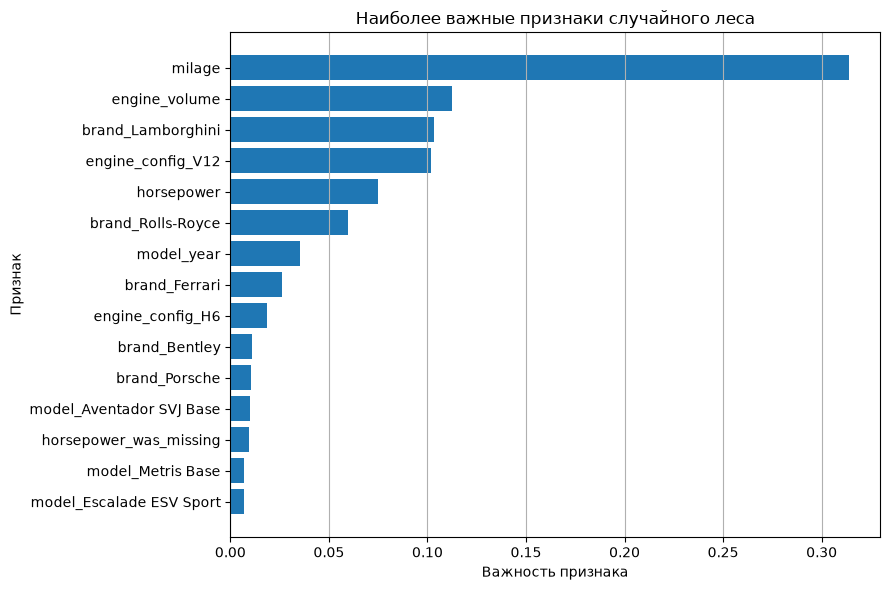

In [382]:
top_features = (
    feature_importance
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    top_features.index,
    top_features.values
)

ax.set_title(
    'Наиболее важные признаки случайного леса'
)

ax.set_xlabel('Важность признака')
ax.set_ylabel('Признак')
ax.grid(axis='x')

fig.tight_layout()
plt.show()

## Линейная регрессия на log(price)

In [383]:
y_train_log = np.log1p(
    y_train
)

log_linear_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        LinearRegression()
    )
])

log_linear_model.fit(
    X_train_without_cylinders,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [384]:
log_predictions = (
    log_linear_model.predict(
        X_test_without_cylinders
    )
)

log_price_predictions = np.expm1(
    log_predictions
)

log_price_predictions = np.maximum(
    log_price_predictions,
    0
)

evaluate_model(
    'Linear Regression log(price)',
    y_test,
    log_price_predictions
)

MAE: 18799.77
RMSE: 138901.06
R2: 0.0561


## Итоговая таблица

In [385]:
results_df = pd.DataFrame(
    model_results
)

results_df = (
    results_df
    .sort_values(
        by='MAE'
    )
    .reset_index(
        drop=True
    )
)

display(results_df)

,Модель,MAE,RMSE,R2
0,Random Forest,16852.88,134695.04,0.1124
1,Linear Regression log(price),18799.77,138901.06,0.0561
2,Lasso Regression,18875.72,137593.43,0.0738
3,Linear Regression,21270.61,138166.62,0.0660


# Проверка гипотез и общие выводы

## Проверка гипотез



### Гипотеза 1

**Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.**

Гипотеза подтвердилась.

Это логично.

### Гипотеза 2

**Добавление элементарных признаков, извлечённых из `engine`, уменьшит ошибку модели на тестовой выборке.**

Гипотеза не подтвердилась для линейной регрессии.

После добавления новых признаков MAE увеличилось на `$132.33`. Разница небольшая, поэтому признаки двигателя не оказали заметного влияния на качество линейной регрессии.

Возможно, часть признаков двигателя дублирует друг друга, их связь с ценой является нелинейной или заполнение пропусков медианой уменьшило их полезность.

---

### Гипотеза 3

**Извлечённый из `engine` признак `horsepower` войдёт в число наиболее важных признаков модели на основе деревьев.**

Гипотеза подтвердилась.

В модели случайного леса `horsepower` занял пятое место по важности. Его важность равна примерно `0.075`.

Следовательно, мощность двигателя является одним из наиболее полезных признаков случайного леса для прогнозирования цены автомобиля.

---

### Гипотеза 4

**Random Forest покажет меньшую ошибку на тестовой выборке, чем линейная регрессия.**

Гипотеза подтвердилась.


Случайный лес имеет меньшие MAE и RMSE, а также большее значение R². Следовательно, он лучше учитывает нелинейные зависимости и взаимодействия между характеристиками автомобиля.

---

### Гипотеза 5

**Обучение линейной регрессии на `log(price)` даст меньшую ошибку, чем обучение на исходном значении `price`.**

Таким образом, логарифмирование уменьшило MAE на `$2 470.84`.

Однако RMSE увеличилось с `$138 166.62` до `$138 901.06`, а R² уменьшилось с `0.0660` до `0.0561`.

Следовательно, логарифмирование улучшило модель по метрике MAE, но не улучшило её по всем рассмотренным метрикам.

Гипотеза частично подтвердилась.

### Гипотеза 6

**Медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.**

Гипотеза подтвердилась.


---

# Общий вывод

Лучшее качество среди рассмотренных моделей показал случайный лес.

Высокое значение RMSE связано с сильной асимметрией целевой переменной и наличием очень дорогих автомобилей. Максимальная цена в датасете равна `$2 954 083`, тогда как медианная цена составляет `$31 000`.

Низкое значение R² показывает, что рассмотренные признаки объясняют цену автомобиля только частично. На стоимость также могут влиять комплектация, техническое состояние, регион продажи, количество владельцев, история обслуживания и другие характеристики, отсутствующие в датасете.

Полученные модели можно рассматривать как базовое решение. Для дальнейшего улучшения качества необходимо проверить подозрительные значения цены, отдельно обработать выбросы, объединить редкие категории.